# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

# Load Dataset

df = pd.read_csv("creditcard.csv")

# Explore Dataset

In [3]:
df.head()

df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Check Fraud Distribution

In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# Visualization

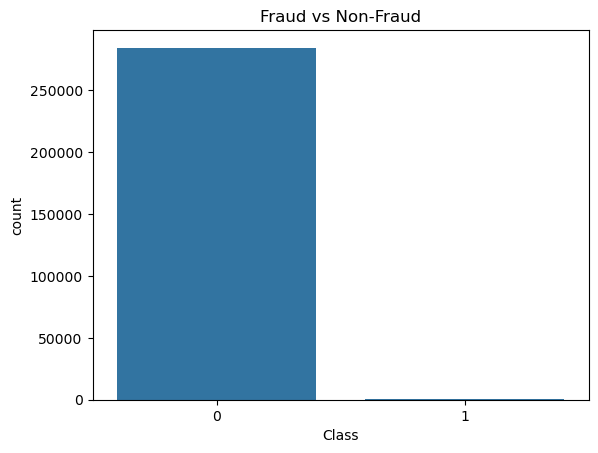

In [5]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# Split Features and Target

In [6]:
X = df.drop("Class", axis=1)

y = df["Class"]

# Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Apply SMOTE

In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Now check:

In [11]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

# Model 1: Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

# Evaluation

In [13]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



# Confusion Matrix

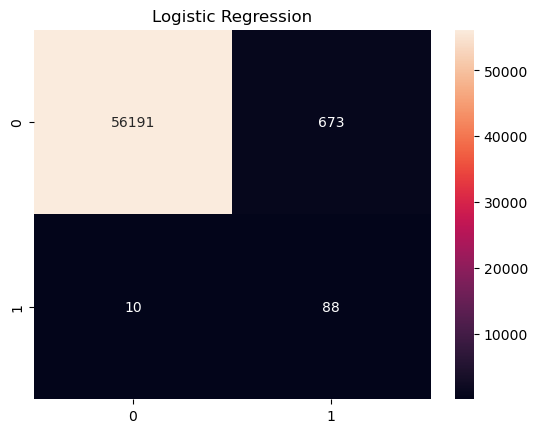

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Logistic Regression")

plt.show()

# Model 2: Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

# Evaluation

In [18]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



# Confusion Matrix

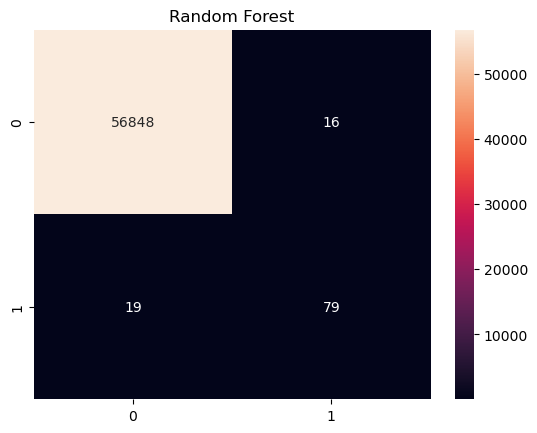

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest")

plt.show()

# ROC-AUC

In [20]:
prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9578066859129696


# ROC Curve

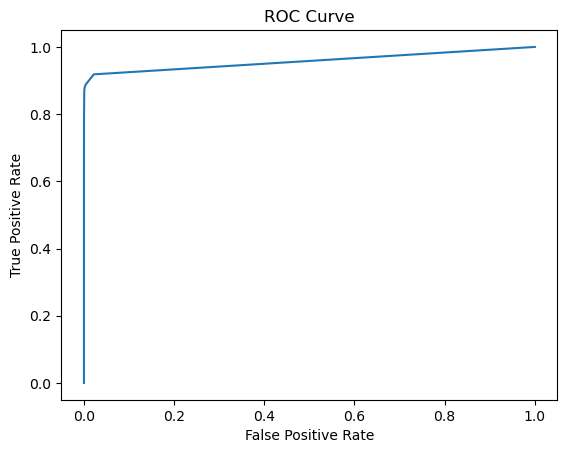

In [21]:
fpr, tpr, threshold = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Final Observations

Write observations such as:

The dataset is highly imbalanced.
SMOTE balanced the training data.
Random Forest performed better than Logistic Regression.
Precision, Recall, F1-score, and ROC-AUC are more appropriate metrics than Accuracy.
The fraud detection model successfully identified most fraudulent transactions.